In [1]:
import pyreadr
import torch

from src.gaussian_mixture import GaussianMixtureMAR
from src.metrics import energy_distance_faster

import numpy as np
import matplotlib.pyplot as plt

Load dataset.

In [2]:
datasets = ["parkinsons", "allergens", "concrete", "windspeed", "forest", "housing", "stock", "pumadyn32nm", "scm20d", "scm1d"]
i = 0 # index of the dataset to use

Xstar_df = pyreadr.read_r(f"datasets/split_test/test.{datasets[i]}.RDS")[None]
X_miss_df = pyreadr.read_r(f"datasets/split_amputed/mar.{datasets[i]}.RDS")[None]

In [3]:
datasets[i]

'parkinsons'

Prepare the data.

In [4]:
Xm = torch.tensor(X_miss_df.values, dtype=torch.float64)
X = torch.nan_to_num(Xm, nan=0.0) # input to GMM

Xstar = torch.tensor(Xstar_df.values)

M_np = (X_miss_df.notna()).astype(int).values
M = torch.tensor(M_np, dtype=torch.float64)

In [6]:
n_samples = X.shape[0]
crit = 'bic'
ct = 'diag'
n_inits = 20

gmm = GaussianMixtureMAR(
            k_range=(1,1000), 
            criterion=crit,
            device='cpu', 
            cov_type=ct, 
            n_init=n_inits
        )
gmm.fit(X, M)

  k=383 -> score=15900.9688
  k=618 -> score=69574.2656
  k=237 -> score=-16171.5859
  k=147 -> score=-36160.8047
  k=91 -> score=-48834.6641
  k=57 -> score=-55926.2383
  k=35 -> score=-59994.0664
  k=22 -> score=-61760.2109
  k=14 -> score=-61869.3594
  k=9 -> score=-59950.0898
  k=17 -> score=-61975.6562
  k=19 -> score=-61917.3672
  k=16 -> score=-62082.5000
  k=15 -> score=-61658.6211


In [7]:
energy_distance_gmm_scaled = [energy_distance_faster(Xstar, gmm.sample(n_samples)[0], scale=True) for _ in range(50)]

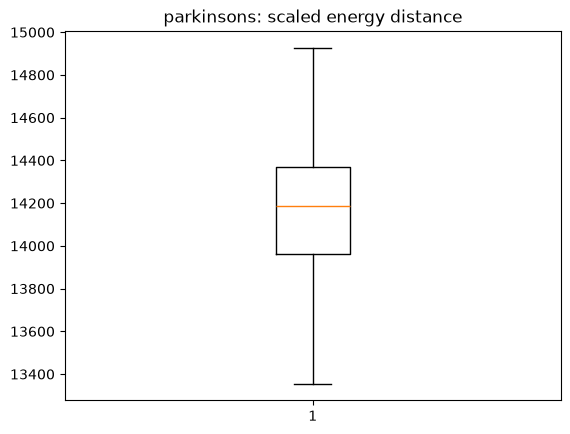

In [8]:
plt.boxplot(energy_distance_gmm_scaled)
plt.title(f'{datasets[i]}: scaled energy distance')
plt.show()